# Experimento comparativo de clustering sobre ESQAD

Este notebook compara cuatro representaciones del corpus ESQAD (BoW, TF-IDF, Nomic embeddings y Qwen3 embeddings) frente a cuatro variantes del mismo esquema de agrupamiento: `kmeans` euclídeo, `kmeans` coseno, `fcm` euclídeo y `fcm` coseno.

El objetivo no es construir una validación exhaustiva en sentido estadístico, sino una comparación formal y práctica que ayude a justificar una elección razonable de representación y método para un generador de FAQ en un chatbot educativo.

La comparación usa información ya obtenida en el EDA previo y los artefactos generados en `validation/results/`, además de métricas internas de validación de agrupamiento: silueta, Calinski-Harabasz, coeficiente de partición, entropía de partición e índice de Xie-Beni.

In [1]:
from __future__ import annotations

import importlib.util
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import calinski_harabasz_score, silhouette_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_colwidth", 120)

In [2]:
# Cargar módulos locales del repositorio sin depender de posibles paquetes instalados en el entorno
CANDIDATE_ROOT = Path.cwd().resolve()
if CANDIDATE_ROOT.name == "notebooks" and CANDIDATE_ROOT.parent.name == "validation":
    ROOT = CANDIDATE_ROOT.parent.parent
else:
    ROOT = next(
        (p for p in [CANDIDATE_ROOT, *CANDIDATE_ROOT.parents] if (p / "validation" / "datasets.py").exists()),
        CANDIDATE_ROOT,
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

def load_local_module(module_name: str, file_path: Path, *, is_package: bool = False):
    spec = importlib.util.spec_from_file_location(
        module_name,
        file_path,
        submodule_search_locations=[str(file_path.parent)] if is_package else None,
    )
    if spec is None or spec.loader is None:
        raise ImportError(f"No se pudo cargar {module_name} desde {file_path}")

    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module

load_local_module("validation", ROOT / "validation" / "__init__.py", is_package=True)
load_local_module("validation.representation", ROOT / "validation" / "representation" / "__init__.py", is_package=True)
local_datasets = load_local_module("validation.datasets", ROOT / "validation" / "datasets.py")
local_bow = load_local_module("validation.representation.bow", ROOT / "validation" / "representation" / "bow.py")
local_ollama = load_local_module("validation.representation.ollama_embeddings", ROOT / "validation" / "representation" / "ollama_embeddings.py")
local_tfidf = load_local_module("validation.representation.tfidf", ROOT / "validation" / "representation" / "tfidf.py")
local_clustering = load_local_module("validation.clustering", ROOT / "validation" / "clustering.py")

DatasetLoader = local_datasets.DatasetLoader
BoWVectorizer = local_bow.BoWVectorizer
OllamaEmbeddings = local_ollama.OllamaEmbeddings
TFIDFVectorizer = local_tfidf.TFIDFVectorizer
GenericKMeans = local_clustering.GenericKMeans
get_closest_to_centroid = local_clustering.get_closest_to_centroid

RESULTS_ROOT = ROOT / "validation" / "results" / "esquad_cluster_methods"
TABLES_DIR = RESULTS_ROOT / "tables"
FIGURES_DIR = RESULTS_ROOT / "figures"
for path in [RESULTS_ROOT, TABLES_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

EDA_TABLES = ROOT / "validation" / "results" / "esquad_eda" / "tables"
UMAP_TABLES = ROOT / "validation" / "results" / "esquad_umap" / "tables"
UMAP_CACHE = ROOT / "validation" / "results" / "esquad_umap" / "cache"

print(f"ROOT: {ROOT}")
print(f"EDA tables: {EDA_TABLES}")
print(f"UMAP tables: {UMAP_TABLES}")
print(f"Experimento: {RESULTS_ROOT}")

/home/gabriel/clase/TFG/TFG-Chatbot/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ROOT: /home/gabriel/clase/TFG/TFG-Chatbot
EDA tables: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/esquad_eda/tables
UMAP tables: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/esquad_umap/tables
Experimento: /home/gabriel/clase/TFG/TFG-Chatbot/validation/results/esquad_cluster_methods


In [3]:
# Cargar la evidencia previa ya generada en EDA y UMAP
quality_summary = pd.read_csv(EDA_TABLES / "quality_summary.csv")
length_summary = pd.read_csv(EDA_TABLES / "length_describe.csv")
representation_stats = pd.read_csv(EDA_TABLES / "representation_stats.csv")
k_scan = pd.read_csv(EDA_TABLES / "k_scan_tfidf_cosine_sample.csv")
sample = pd.read_csv(UMAP_TABLES / "esquad_umap_sample.csv")

sample["text"] = sample["text"].astype(str).str.strip()
sample = sample[sample["text"].str.len() > 0].drop_duplicates(subset=["text"]).reset_index(drop=True)
sample_work = sample.copy()

print(f"Corpus limpio disponible: {len(sample)}")
print(f"Dataset de trabajo (completo): {len(sample_work)}")
display(quality_summary)
display(length_summary)
display(representation_stats)
display(k_scan)
display(sample_work[["text", "char_len", "tok_len"]].head())

Corpus limpio disponible: 500
Dataset de trabajo (completo): 500


,n_rows,n_missing_text,n_empty_or_blank,n_duplicates_exact,dup_rate
0,1190,0,0,6,0.005042


,Unnamed: 0,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
0,char_len,1184.0,68.238176,24.633867,15.0,40.0,51.0,65.0,82.25,99.0,110.0,226.0
1,tok_len,1184.0,11.313345,4.146182,3.0,7.0,8.0,11.0,14.00,17.0,18.0,35.0


,representation,n_samples,n_features,nnz,sparsity,avg_nnz_per_doc
0,bow,1184,2713,15964,0.99503,13.483108
1,tfidf,1184,2713,15964,0.99503,13.483108


,k,asw_cosine
0,2,0.010413
1,3,0.014366
2,4,0.017431
3,5,0.018017
4,6,0.024283
5,7,0.025240
6,8,0.023707
7,9,0.029914
8,10,0.030269
9,11,0.033657


,text,char_len,tok_len
0,"En Estados Unidos, ¿cuál es la velocidad habitual de una turbina con 60 Hertz de potencia?",90,16
1,¿Cuándo visitó Obama a Kenia finalmente?,40,6
2,¿Como qué libro fueron publicadas las siete conferencias en inglés de Iqbal?,76,12
3,¿Qué porcentaje de la población de Varsovia era protestante en 1901?,68,11
4,¿Qué sucedió cuando se asimilaron las cianobacterias?,53,7


In [4]:
# Construir las cuatro representaciones sobre el dataset completo
texts = sample_work["text"].tolist()

bow_vectorizer = BoWVectorizer(max_features=2000, min_df=2)
tfidf_vectorizer = TFIDFVectorizer(max_features=2000, min_df=2)

X_bow = bow_vectorizer.fit_transform(texts).astype(np.float32)
X_tfidf = tfidf_vectorizer.fit_transform(texts).astype(np.float32)

ollama_host = os.getenv("OLLAMA_HOST", "localhost")
ollama_port = int(os.getenv("OLLAMA_PORT", "11434"))
nomic_embedder = OllamaEmbeddings(model="nomic-embed-text", host=ollama_host, port=ollama_port)
qwen_embedder = OllamaEmbeddings(model="qwen3-embedding:0.6b", host=ollama_host, port=ollama_port)
nomic_cache = UMAP_CACHE / f"nomic_embeddings_n{len(sample)}.npy"
qwen_cache = UMAP_CACHE / f"qwen3_embeddings_n{len(sample)}.npy"

def load_or_compute_embeddings(embedder, cache_path: Path, texts_: list[str]) -> np.ndarray:
    if cache_path.exists():
        return np.load(cache_path)
    X = embedder.embed_batch(texts_).astype(np.float32)
    np.save(cache_path, X)
    return X

X_nomic = load_or_compute_embeddings(nomic_embedder, nomic_cache, sample_work["text"].tolist())
X_qwen = load_or_compute_embeddings(qwen_embedder, qwen_cache, sample_work["text"].tolist())

representations = {
    "bow": X_bow,
    "tfidf": X_tfidf,
    "nomic": X_nomic,
    "qwen3": X_qwen,
}

for name, X in representations.items():
    print(name, X.shape)

bow (500, 314)
tfidf (500, 314)
nomic (500, 768)
qwen3 (500, 1024)


In [5]:
# Funciones de validación interna y difusa
def l2_normalize(X: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return X / norms

def prepared_matrix(X: np.ndarray, distance: str) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64)
    return l2_normalize(X) if distance == "cosine" else X

def partition_coefficient(membership: np.ndarray) -> float:
    return float(np.mean(np.sum(membership ** 2, axis=1)))

def partition_entropy(membership: np.ndarray) -> float:
    u = np.clip(membership, 1e-12, 1.0)
    return float(-np.mean(np.sum(u * np.log(u), axis=1)))

def xie_beni_index(X_eval: np.ndarray, centroids: np.ndarray, membership: np.ndarray, m: float = 2.0) -> float:
    distances = np.linalg.norm(X_eval[:, None, :] - centroids[None, :, :], axis=2)
    numerator = float(np.sum((membership ** m) * (distances ** 2)))
    centroid_distances = np.linalg.norm(centroids[:, None, :] - centroids[None, :, :], axis=2)
    np.fill_diagonal(centroid_distances, np.inf)
    min_sep_sq = float(np.min(centroid_distances ** 2))
    if not np.isfinite(min_sep_sq) or min_sep_sq <= 0:
        return float("inf")
    return numerator / (X_eval.shape[0] * min_sep_sq)

def evaluate_configuration(rep_name: str, X_raw: np.ndarray, algorithm: str, distance: str, k: int, random_state: int = 42) -> dict:
    model = GenericKMeans(
        n_clusters=k,
        algorithm=algorithm,
        distance=distance,
        random_state=random_state,
        max_iter=200,
        tol=1e-4,
        m=2.0,
    )
    labels = model.fit_predict(X_raw)
    X_eval = prepared_matrix(X_raw, distance)
    metric = "cosine" if distance == "cosine" else "euclidean"
    
    # Verificar que el número de clusters únicos es válido
    n_unique_labels = len(np.unique(labels))
    if n_unique_labels < 2:
        # Si converge a 1 cluster, retornar NaN para métricas
        silhouette = np.nan
        ch_score = np.nan
    else:
        try:
            silhouette = float(silhouette_score(X_eval, labels, metric=metric))
            ch_score = float(calinski_harabasz_score(X_eval, labels))
        except ValueError:
            # Si aún hay error, usar NaN
            silhouette = np.nan
            ch_score = np.nan

    row = {
        "representation": rep_name,
        "algorithm": algorithm,
        "distance": distance,
        "method": f"{algorithm}_{distance}",
        "k": int(k),
        "random_state": int(random_state),
        "silhouette": silhouette,
        "calinski_harabasz": ch_score,
        "inertia": float(model.inertia_),
        "n_iter": int(model.n_iter_),
        "n_unique_labels": int(n_unique_labels),
    }

    if algorithm == "fcm":
        assert model.membership_ is not None and model.centroids_ is not None
        row.update({
            "partition_coefficient": partition_coefficient(model.membership_),
            "partition_entropy": partition_entropy(model.membership_),
            "xie_beni": xie_beni_index(X_eval, model.centroids_, model.membership_, m=model.m),
        })
    else:
        row.update({
            "partition_coefficient": np.nan,
            "partition_entropy": np.nan,
            "xie_beni": np.nan,
        })

    return row

METHOD_SPECS = [
    ("kmeans", "euclidean"),
    ("kmeans", "cosine"),
    ("fcm", "euclidean"),
    ("fcm", "cosine"),
]
K_VALUES = list(range(2, 13))
RANDOM_SEEDS = [42, 123, 456, 789, 1011, 1213, 1415, 1617, 1819, 2021]  # 10 semillas para robustez

In [6]:
# Ejecutar el barrido de configuraciones con múltiples semillas
rows = []
for rep_name, X in representations.items():
    print(f"Procesando representación: {rep_name}")
    for algorithm, distance in METHOD_SPECS:
        print(f"  - {algorithm}_{distance}")
        for k in K_VALUES:
            for random_state in RANDOM_SEEDS:
                rows.append(evaluate_configuration(rep_name, X, algorithm, distance, k, random_state=random_state))

results_df = pd.DataFrame(rows)

# Filtrar filas donde el clustering falló (n_unique_labels < 2)
n_failed = len(results_df[results_df["n_unique_labels"] < 2])
if n_failed > 0:
    print(f"\n⚠️ ADVERTENCIA: {n_failed} configuraciones convergieron a <2 clusters (filtradas)")
    results_df_valid = results_df[results_df["n_unique_labels"] >= 2].copy()
else:
    results_df_valid = results_df.copy()

results_df.to_csv(TABLES_DIR / "cluster_validation_grid_full.csv", index=False, encoding="utf-8")
results_df_valid.to_csv(TABLES_DIR / "cluster_validation_grid_valid.csv", index=False, encoding="utf-8")

print(f"\nTotal de combinaciones evaluadas: {len(results_df)}")
print(f"Combinaciones válidas (n_clusters >= 2): {len(results_df_valid)}")
print(f"Semillas utilizadas: {RANDOM_SEEDS}")
display(results_df_valid.head(10))
display(results_df_valid.groupby(["representation", "method"])[["silhouette", "calinski_harabasz"]].agg(["mean", "std"]).round(4))

Procesando representación: bow
  - kmeans_euclidean
  - kmeans_cosine
  - fcm_euclidean
  - fcm_cosine
Procesando representación: tfidf
  - kmeans_euclidean
  - kmeans_cosine
  - fcm_euclidean
  - fcm_cosine
Procesando representación: nomic
  - kmeans_euclidean
  - kmeans_cosine
  - fcm_euclidean
  - fcm_cosine
Procesando representación: qwen3
  - kmeans_euclidean
  - kmeans_cosine
  - fcm_euclidean
  - fcm_cosine

Total de combinaciones evaluadas: 1760
Combinaciones válidas (n_clusters >= 2): 1760
Semillas utilizadas: [42, 123, 456, 789, 1011, 1213, 1415, 1617, 1819, 2021]


,representation,algorithm,distance,method,k,random_state,silhouette,calinski_harabasz,inertia,n_iter,n_unique_labels,partition_coefficient,partition_entropy,xie_beni
0,bow,kmeans,euclidean,kmeans_euclidean,2,42,0.055005,1.985568,429.670751,2,2,NaN,NaN,NaN
1,bow,kmeans,euclidean,kmeans_euclidean,2,123,0.053353,4.051818,427.902394,2,2,NaN,NaN,NaN
2,bow,kmeans,euclidean,kmeans_euclidean,2,456,0.053355,3.052685,428.755660,2,2,NaN,NaN,NaN
3,bow,kmeans,euclidean,kmeans_euclidean,2,789,0.058994,7.883302,424.661526,3,2,NaN,NaN,NaN
4,bow,kmeans,euclidean,kmeans_euclidean,2,1011,0.055116,2.643424,429.106155,2,2,NaN,NaN,NaN
5,bow,kmeans,euclidean,kmeans_euclidean,2,1213,0.055005,1.985568,429.670751,2,2,NaN,NaN,NaN
6,bow,kmeans,euclidean,kmeans_euclidean,2,1415,0.057688,5.799491,426.418007,4,2,NaN,NaN,NaN
7,bow,kmeans,euclidean,kmeans_euclidean,2,1617,0.052555,2.612860,429.132353,2,2,NaN,NaN,NaN
8,bow,kmeans,euclidean,kmeans_euclidean,2,1819,0.053269,2.486618,429.240597,2,2,NaN,NaN,NaN
9,bow,kmeans,euclidean,kmeans_euclidean,2,2021,0.058994,7.883302,424.661526,2,2,NaN,NaN,NaN


silhouette         calinski_harabasz        
                                      mean     std              mean     std
representation method                                                       
bow            fcm_cosine           0.0374  0.0145            5.8799  1.0628
               fcm_euclidean        0.0377  0.0014            2.8032  0.5328
               kmeans_cosine        0.0286  0.0139            3.9772  0.5520
               kmeans_euclidean     0.0680  0.0117            3.9262  1.4118
nomic          fcm_cosine          -0.0045  0.0228            6.0005  2.1593
               fcm_euclidean       -0.0164  0.0213            5.8813  2.9972
               kmeans_cosine        0.0417  0.0227            8.4074  3.1302
               kmeans_euclidean     0.0206  0.0126            8.4533  3.1967
qwen3          fcm_cosine           0.0146  0.0077            5.2569  1.3172
               fcm_euclidean        0.0033  0.0102            5.7639  1.8996
               kmeans_cosine        0.0413  0.0051            7.5531  1.9929
               kmeans_euclidean     0.0227  0.0032            7.6713  1.9380
tfidf          fcm_cosine           0.0252  0.0103            4.2730  0.7284
               fcm_euclidean        0.0321  0.0019            2.2692  0.4736
               kmeans_cosine        0.0266  0.0118            3.7725  0.3729
               kmeans_euclidean     0.0634  0.0071            3.1812  0.8737

In [7]:
# Resumen de mejores valores por configuración y criterio (usando resultados individuales por semilla)
summary_rows = []
for (rep_name, method), group in results_df_valid.groupby(["representation", "method"]):
    is_fcm = method.startswith("fcm")
    best_sil = group.loc[group["silhouette"].idxmax()]
    best_ch = group.loc[group["calinski_harabasz"].idxmax()]

    if is_fcm:
        best_pc = group.loc[group["partition_coefficient"].idxmax()]
        best_pe = group.loc[group["partition_entropy"].idxmin()]
        best_xb = group.loc[group["xie_beni"].idxmin()]
        tmp = group.copy()
        tmp["consensus_score"] = (
            (tmp["silhouette"] - tmp["silhouette"].mean()) / (tmp["silhouette"].std(ddof=0) or 1.0) +
            (tmp["calinski_harabasz"] - tmp["calinski_harabasz"].mean()) / (tmp["calinski_harabasz"].std(ddof=0) or 1.0) +
            (tmp["partition_coefficient"] - tmp["partition_coefficient"].mean()) / (tmp["partition_coefficient"].std(ddof=0) or 1.0) -
            (tmp["partition_entropy"] - tmp["partition_entropy"].mean()) / (tmp["partition_entropy"].std(ddof=0) or 1.0) -
            (tmp["xie_beni"] - tmp["xie_beni"].mean()) / (tmp["xie_beni"].std(ddof=0) or 1.0)
        ) / 5.0
    else:
        best_pc = None
        best_pe = None
        best_xb = None
        tmp = group.copy()
        tmp["consensus_score"] = (
            (tmp["silhouette"] - tmp["silhouette"].mean()) / (tmp["silhouette"].std(ddof=0) or 1.0) +
            (tmp["calinski_harabasz"] - tmp["calinski_harabasz"].mean()) / (tmp["calinski_harabasz"].std(ddof=0) or 1.0)
        ) / 2.0

    consensus = tmp.loc[tmp["consensus_score"].idxmax()]
    summary_rows.append({
        "representation": rep_name,
        "method": method,
        "best_k_silhouette": int(best_sil["k"]),
        "best_silhouette": float(best_sil["silhouette"]),
        "best_k_ch": int(best_ch["k"]),
        "best_ch": float(best_ch["calinski_harabasz"]),
        "best_k_consensus": int(consensus["k"]),
        "consensus_score": float(consensus["consensus_score"]),
        "pc_at_consensus": float(consensus["partition_coefficient"]) if is_fcm else np.nan,
        "pe_at_consensus": float(consensus["partition_entropy"]) if is_fcm else np.nan,
        "xb_at_consensus": float(consensus["xie_beni"]) if is_fcm else np.nan,
    })

summary_df = pd.DataFrame(summary_rows).sort_values(["representation", "method"]).reset_index(drop=True)
summary_df.to_csv(TABLES_DIR / "comparison_summary.csv", index=False, encoding="utf-8")
display(summary_df)

,representation,method,best_k_silhouette,best_silhouette,best_k_ch,best_ch,best_k_consensus,consensus_score,pc_at_consensus,pe_at_consensus,xb_at_consensus
0,bow,fcm_cosine,10,0.072400,3,8.438671,2,1.012261,0.509506,0.682798,1.398929e+00
1,bow,fcm_euclidean,2,0.046578,2,5.002152,2,3.012877,0.500000,0.693147,2.943630e+09
2,bow,kmeans_cosine,12,0.063484,2,6.082952,12,1.674090,NaN,NaN,NaN
3,bow,kmeans_euclidean,12,0.098727,3,8.055234,12,1.767816,NaN,NaN,NaN
4,nomic,fcm_cosine,2,0.060734,2,13.820429,2,2.472303,0.500009,0.693138,3.059839e+04
5,nomic,fcm_euclidean,2,0.034550,2,15.241956,2,2.210770,0.500000,0.693147,1.104639e+09
6,nomic,kmeans_cosine,2,0.140217,2,16.571612,2,3.462800,NaN,NaN,NaN
7,nomic,kmeans_euclidean,2,0.073418,2,16.571613,2,3.361139,NaN,NaN,NaN
8,qwen3,fcm_cosine,2,0.032780,2,9.550437,2,2.120735,0.500019,0.693128,9.401088e+03
9,qwen3,fcm_euclidean,2,0.022026,2,12.194349,2,2.167976,0.500000,0.693147,4.301534e+10


In [8]:
# Agregar resultados: media y desviación estándar por configuración
robust_rows = []
for (rep_name, method, k), group in results_df_valid.groupby(["representation", "method", "k"]):
    is_fcm = method.startswith("fcm")
    
    robust_rows.append({
        "representation": rep_name,
        "method": method,
        "k": int(k),
        "silhouette_mean": float(group["silhouette"].mean()),
        "silhouette_std": float(group["silhouette"].std()),
        "calinski_harabasz_mean": float(group["calinski_harabasz"].mean()),
        "calinski_harabasz_std": float(group["calinski_harabasz"].std()),
        "inertia_mean": float(group["inertia"].mean()),
        "inertia_std": float(group["inertia"].std()),
        "partition_coefficient_mean": float(group["partition_coefficient"].mean()) if is_fcm else np.nan,
        "partition_coefficient_std": float(group["partition_coefficient"].std()) if is_fcm else np.nan,
        "partition_entropy_mean": float(group["partition_entropy"].mean()) if is_fcm else np.nan,
        "partition_entropy_std": float(group["partition_entropy"].std()) if is_fcm else np.nan,
        "xie_beni_mean": float(group["xie_beni"].mean()) if is_fcm else np.nan,
        "xie_beni_std": float(group["xie_beni"].std()) if is_fcm else np.nan,
        "n_seeds": int(len(group)),
    })

robust_df = pd.DataFrame(robust_rows)
robust_df.to_csv(TABLES_DIR / "cluster_validation_grid_robust.csv", index=False, encoding="utf-8")

print(f"Resultados agregados sobre {len(RANDOM_SEEDS)} semillas:")
display(robust_df.head(15))

Resultados agregados sobre 10 semillas:


,representation,method,k,silhouette_mean,silhouette_std,calinski_harabasz_mean,calinski_harabasz_std,inertia_mean,inertia_std,partition_coefficient_mean,partition_coefficient_std,partition_entropy_mean,partition_entropy_std,xie_beni_mean,xie_beni_std,n_seeds
0,bow,fcm_cosine,2,0.012781,0.002935,5.973379,2.230279e+00,211.755584,3.239135e-02,0.509746,1.372438e-04,0.682524,1.572052e-04,1.373858e+00,1.411659e-02,10
1,bow,fcm_cosine,3,0.019750,0.003791,5.715413,1.338810e+00,142.500943,6.176772e-01,0.355400,4.289048e-03,1.066381,6.089487e-03,8.049111e+02,2.371930e+03,10
2,bow,fcm_cosine,4,0.030712,0.003499,6.792954,8.370758e-01,106.869994,6.047408e-01,0.275843,5.837459e-03,1.341447,9.968253e-03,4.778427e+03,1.445139e+04,10
3,bow,fcm_cosine,5,0.035260,0.004883,6.245071,8.279472e-01,85.440551,7.089072e-01,0.229216,9.449582e-03,1.552265,1.831836e-02,9.795661e+03,1.179245e+04,10
4,bow,fcm_cosine,6,0.038520,0.007544,6.023159,6.958623e-01,70.974428,4.243273e-01,0.196811,8.358106e-03,1.726977,1.782799e-02,4.065668e+05,9.242145e+05,10
5,bow,fcm_cosine,7,0.045161,0.014811,6.305155,7.563649e-01,60.533362,3.716761e-01,0.168313,1.190636e-02,1.886715,2.739644e-02,3.025562e+06,9.462299e+06,10
6,bow,fcm_cosine,8,0.041086,0.008422,5.425819,7.469418e-01,52.750582,1.289918e-01,0.146675,7.103564e-03,2.025686,1.742017e-02,3.099751e+05,9.384976e+05,10
7,bow,fcm_cosine,9,0.050899,0.010383,5.917609,7.435212e-01,46.920981,1.383185e-01,0.137167,6.231940e-03,2.128636,1.605323e-02,8.987888e+07,2.837178e+08,10
8,bow,fcm_cosine,10,0.048182,0.011393,5.690736,7.371218e-01,42.140619,8.552134e-02,0.125922,7.255749e-03,2.231430,1.930961e-02,3.153285e+08,9.967471e+08,10
9,bow,fcm_cosine,11,0.043943,0.012632,5.236194,4.735708e-01,38.347165,8.842731e-02,0.120884,6.606339e-03,2.311224,1.801322e-02,1.078528e+07,2.750825e+07,10


In [9]:
# Análisis de consenso robusto: identificar mejor configuración usando promedios
robust_summary_rows = []
for (rep_name, method), group in robust_df.groupby(["representation", "method"]):
    is_fcm = method.startswith("fcm")
    best_sil = group.loc[group["silhouette_mean"].idxmax()]
    best_ch = group.loc[group["calinski_harabasz_mean"].idxmax()]

    if is_fcm:
        tmp = group.copy()
        tmp["consensus_score"] = (
            (tmp["silhouette_mean"] - tmp["silhouette_mean"].mean()) / (tmp["silhouette_mean"].std(ddof=0) or 1.0) +
            (tmp["calinski_harabasz_mean"] - tmp["calinski_harabasz_mean"].mean()) / (tmp["calinski_harabasz_mean"].std(ddof=0) or 1.0) +
            (tmp["partition_coefficient_mean"] - tmp["partition_coefficient_mean"].mean()) / (tmp["partition_coefficient_mean"].std(ddof=0) or 1.0) -
            (tmp["partition_entropy_mean"] - tmp["partition_entropy_mean"].mean()) / (tmp["partition_entropy_mean"].std(ddof=0) or 1.0) -
            (tmp["xie_beni_mean"] - tmp["xie_beni_mean"].mean()) / (tmp["xie_beni_mean"].std(ddof=0) or 1.0)
        ) / 5.0
    else:
        tmp = group.copy()
        tmp["consensus_score"] = (
            (tmp["silhouette_mean"] - tmp["silhouette_mean"].mean()) / (tmp["silhouette_mean"].std(ddof=0) or 1.0) +
            (tmp["calinski_harabasz_mean"] - tmp["calinski_harabasz_mean"].mean()) / (tmp["calinski_harabasz_mean"].std(ddof=0) or 1.0)
        ) / 2.0

    consensus = tmp.loc[tmp["consensus_score"].idxmax()]
    robust_summary_rows.append({
        "representation": rep_name,
        "method": method,
        "best_k_silhouette": int(best_sil["k"]),
        "best_silhouette_mean": float(best_sil["silhouette_mean"]),
        "best_silhouette_std": float(best_sil["silhouette_std"]),
        "best_k_ch": int(best_ch["k"]),
        "best_ch_mean": float(best_ch["calinski_harabasz_mean"]),
        "best_ch_std": float(best_ch["calinski_harabasz_std"]),
        "best_k_consensus": int(consensus["k"]),
        "consensus_score": float(consensus["consensus_score"]),
        "silhouette_mean_at_consensus": float(consensus["silhouette_mean"]),
        "silhouette_std_at_consensus": float(consensus["silhouette_std"]),
        "calinski_harabasz_mean_at_consensus": float(consensus["calinski_harabasz_mean"]),
        "calinski_harabasz_std_at_consensus": float(consensus["calinski_harabasz_std"]),
    })

robust_summary_df = pd.DataFrame(robust_summary_rows).sort_values(["representation", "method"]).reset_index(drop=True)
robust_summary_df.to_csv(TABLES_DIR / "comparison_summary_robust.csv", index=False, encoding="utf-8")

print("Resumen robusto por representación y método (media ± std sobre todas las semillas):")
display(robust_summary_df)

Resumen robusto por representación y método (media ± std sobre todas las semillas):


,representation,method,best_k_silhouette,best_silhouette_mean,best_silhouette_std,best_k_ch,best_ch_mean,best_ch_std,best_k_consensus,consensus_score,silhouette_mean_at_consensus,silhouette_std_at_consensus,calinski_harabasz_mean_at_consensus,calinski_harabasz_std_at_consensus
0,bow,fcm_cosine,9,0.050899,0.010383,4,6.792954,0.837076,4,0.643474,0.030712,0.003499,6.792954,0.837076
1,bow,fcm_euclidean,2,0.041036,0.002046,2,4.310995,0.251007,2,2.225227,0.041036,0.002046,4.310995,0.251007
2,bow,kmeans_cosine,12,0.048566,0.009683,2,4.079592,1.048761,12,0.795530,0.048566,0.009683,3.975746,0.366713
3,bow,kmeans_euclidean,12,0.077903,0.013268,6,4.248153,1.695987,6,1.087750,0.068167,0.010146,4.248153,1.695987
4,nomic,fcm_cosine,2,0.039271,0.012490,2,10.227615,2.637173,2,1.520577,0.039271,0.012490,10.227615,2.637173
5,nomic,fcm_euclidean,2,0.028332,0.007540,2,13.008726,2.881846,2,2.189044,0.028332,0.007540,13.008726,2.881846
6,nomic,kmeans_cosine,2,0.102650,0.022253,2,16.275728,0.177266,2,2.793692,0.102650,0.022253,16.275728,0.177266
7,nomic,kmeans_euclidean,2,0.054177,0.010244,2,16.347498,0.157548,2,2.780765,0.054177,0.010244,16.347498,0.157548
8,qwen3,fcm_cosine,2,0.026143,0.005113,2,7.795364,1.316345,2,1.743147,0.026143,0.005113,7.795364,1.316345
9,qwen3,fcm_euclidean,2,0.017228,0.003254,2,9.663384,1.688387,2,2.225452,0.017228,0.003254,9.663384,1.688387


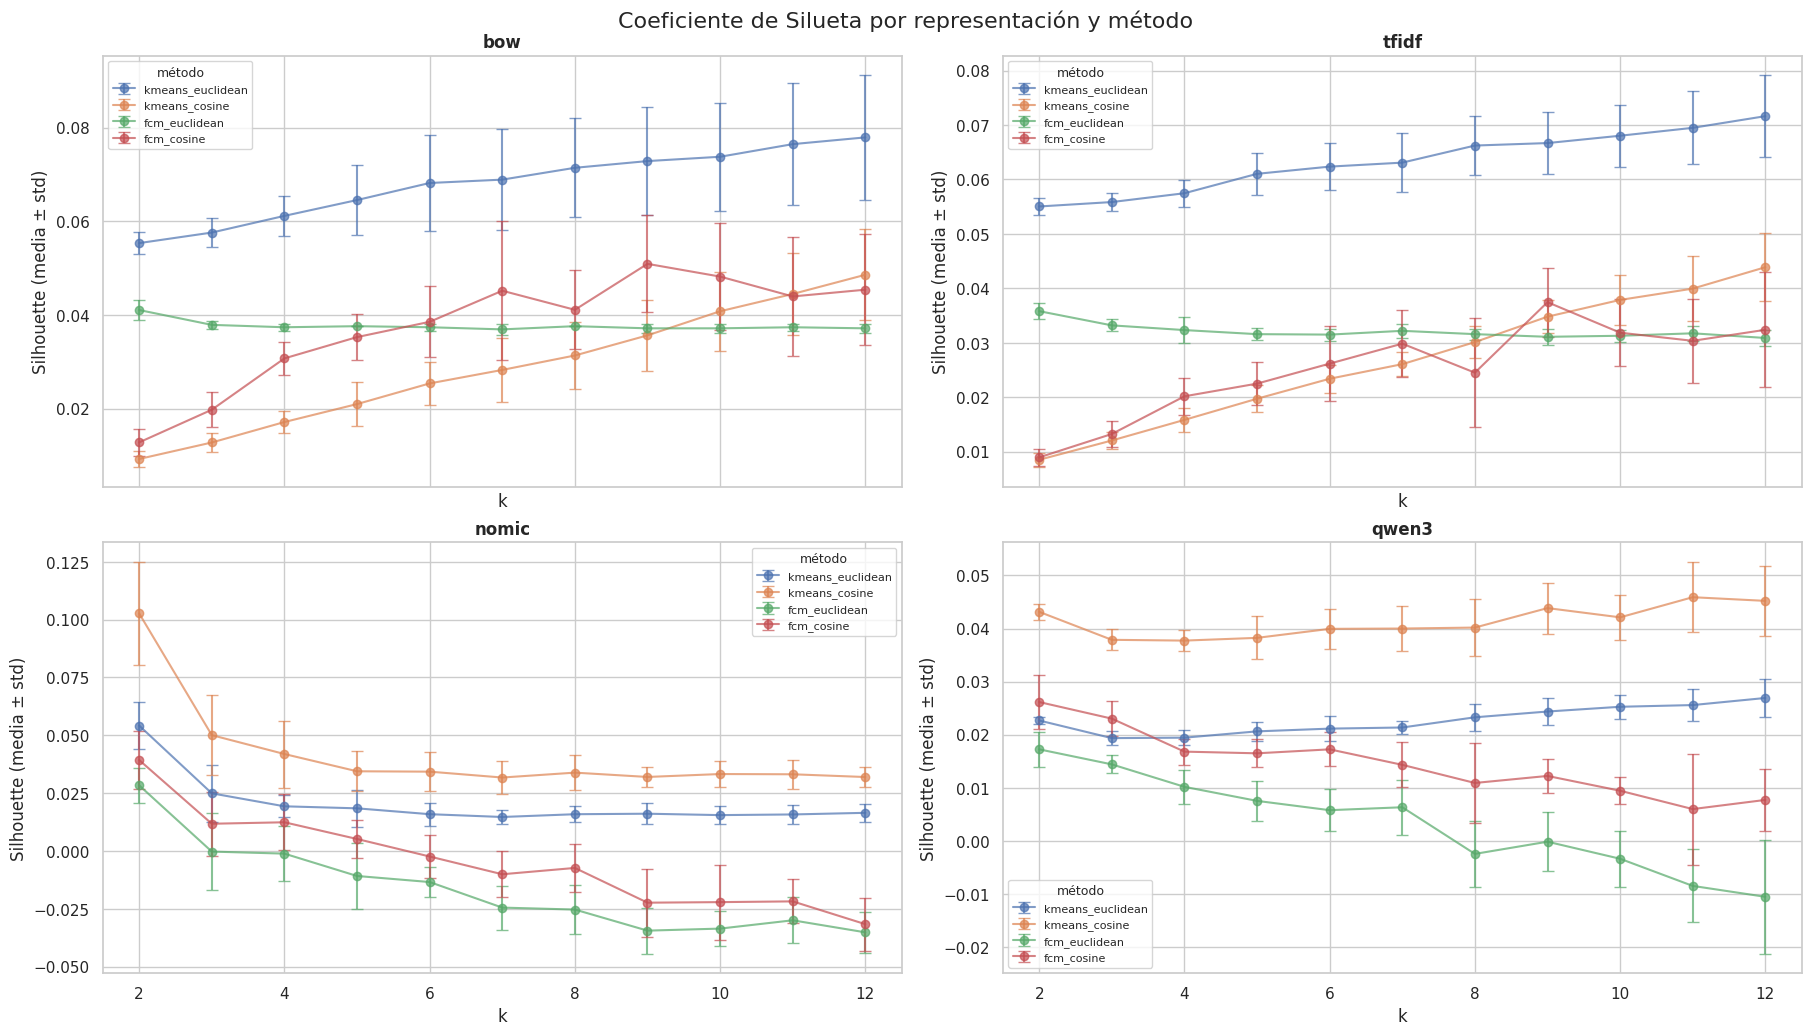

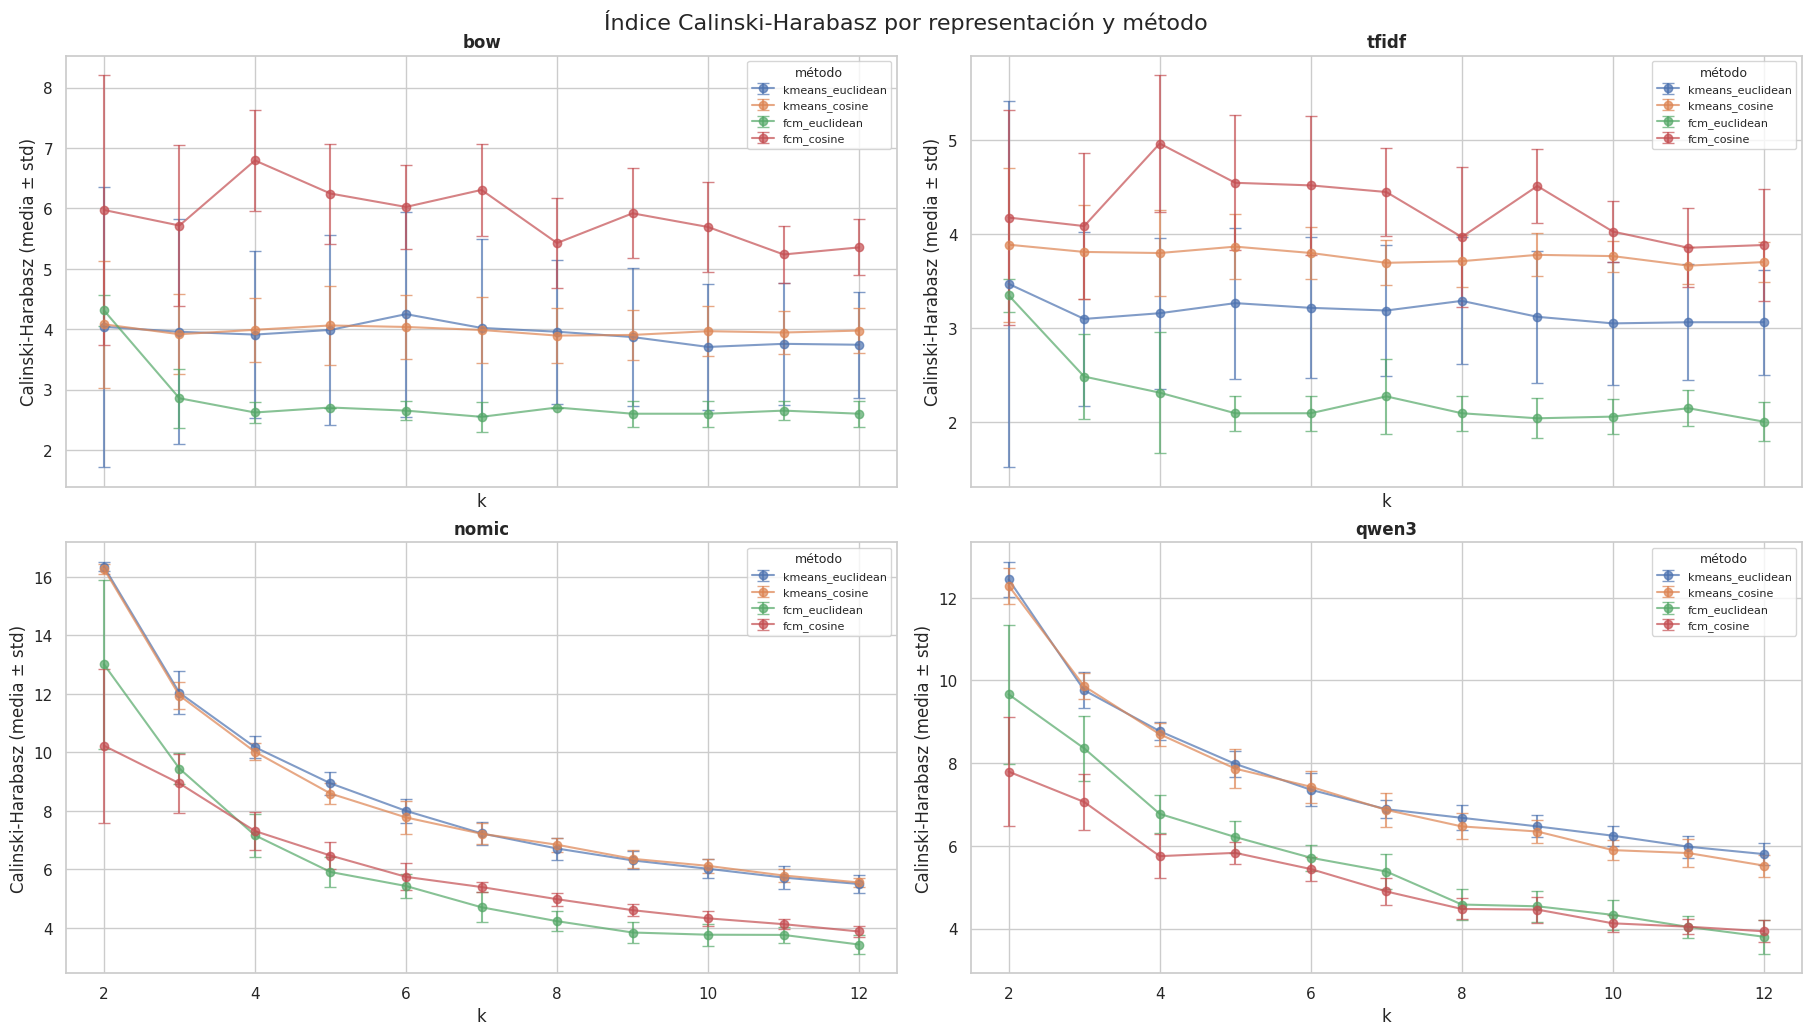

In [10]:
# Curvas de silueta y Calinski-Harabasz por representación y método (con barras de error)
def plot_metric_grid_robust(metric_mean: str, metric_std: str, ylabel: str, title: str, methods: list[str]) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True, constrained_layout=True)
    axes = axes.flatten()
    for ax, rep_name in zip(axes, representations.keys()):
        subset = robust_df[robust_df["representation"] == rep_name]
        for method in methods:
            method_data = subset[subset["method"] == method].sort_values("k")
            if len(method_data) > 0:
                ax.errorbar(
                    method_data["k"],
                    method_data[metric_mean],
                    yerr=method_data[metric_std],
                    marker="o",
                    label=method,
                    capsize=4,
                    alpha=0.7,
                )
        ax.set_title(rep_name)
        ax.set_xlabel("k")
        ax.set_ylabel(ylabel)
        ax.legend(title="método", fontsize=8, title_fontsize=9)
    fig.suptitle(title, fontsize=16, y=1.02)
    fig.savefig(FIGURES_DIR / f"{metric_mean}_grid_robust.png", dpi=180, bbox_inches="tight")
    plt.show()

plot_metric_grid_robust("silhouette_mean", "silhouette_std", "Silhouette (media ± std)", 
                        "Coeficiente de Silueta por representación y método", 
                        ["kmeans_euclidean", "kmeans_cosine", "fcm_euclidean", "fcm_cosine"])
plot_metric_grid_robust("calinski_harabasz_mean", "calinski_harabasz_std", "Calinski-Harabasz (media ± std)", 
                        "Índice Calinski-Harabasz por representación y método", 
                        ["kmeans_euclidean", "kmeans_cosine", "fcm_euclidean", "fcm_cosine"])

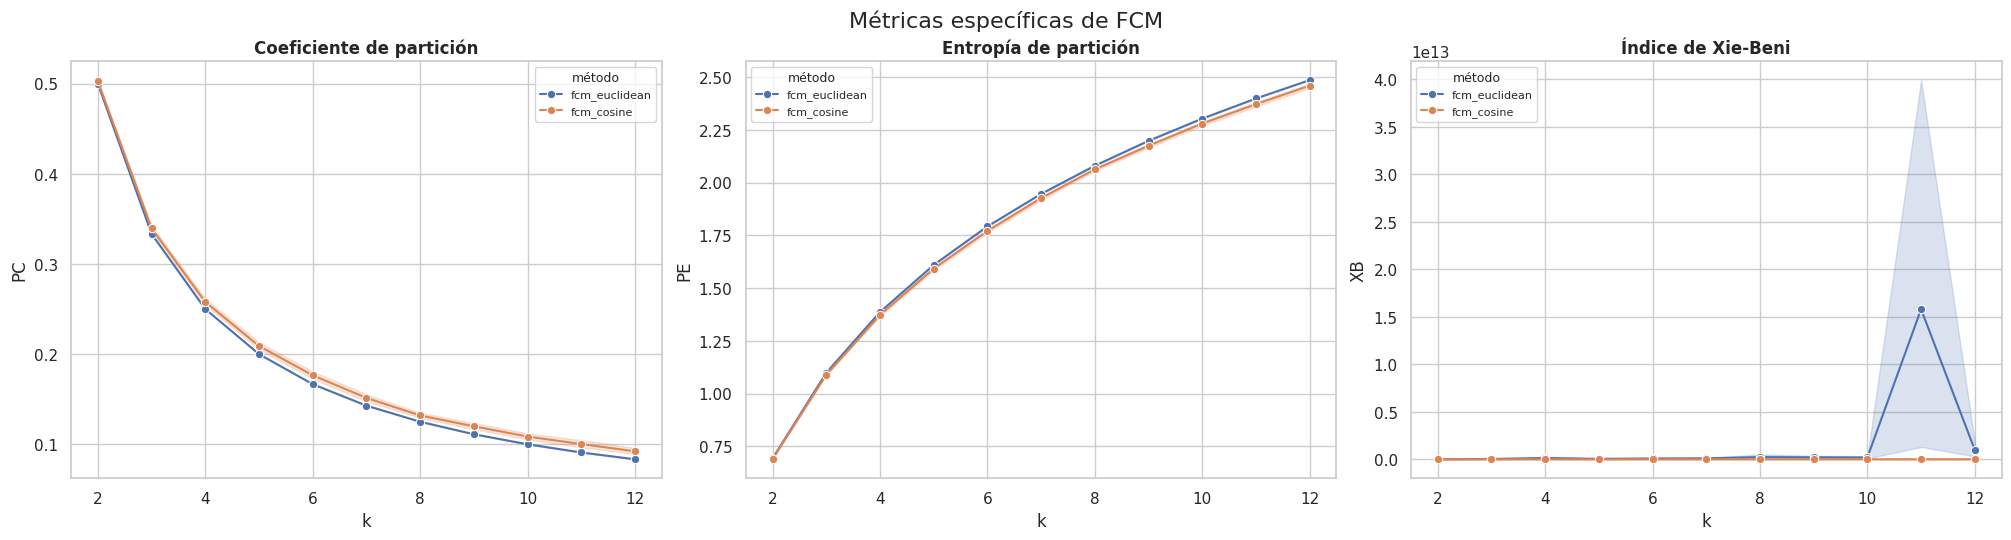

In [11]:
# Métricas específicas de FCM: coeficiente de partición, entropía e índice de Xie-Beni
fcm_df = results_df_valid[results_df_valid["method"].str.startswith("fcm")].copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=True, constrained_layout=True)
for ax, metric, ylabel, title in [
    (axes[0], "partition_coefficient", "PC", "Coeficiente de partición"),
    (axes[1], "partition_entropy", "PE", "Entropía de partición"),
    (axes[2], "xie_beni", "XB", "Índice de Xie-Beni"),
]:
    sns.lineplot(data=fcm_df, x="k", y=metric, hue="method", marker="o", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("k")
    ax.set_ylabel(ylabel)
    ax.legend(title="método", fontsize=8, title_fontsize=9)

fig.suptitle("Métricas específicas de FCM", fontsize=16, y=1.05)
fig.savefig(FIGURES_DIR / "fcm_internal_metrics.png", dpi=180, bbox_inches="tight")
plt.show()

In [12]:
# Selección práctica de configuración recomendada (basada en análisis robusto)
best_overall = robust_summary_df.sort_values("consensus_score", ascending=False).iloc[0]
best_rep = str(best_overall["representation"])
best_method = str(best_overall["method"])
best_k = int(best_overall["best_k_consensus"])
best_algorithm, best_distance = best_method.split("_", 1)

print("Configuración recomendada por consenso heurístico (análisis robusto):")
print(f"- representación: {best_rep}")
print(f"- método: {best_method}")
print(f"- k: {best_k}")
print(f"- silueta media: {best_overall['silhouette_mean_at_consensus']:.4f} ± {best_overall['silhouette_std_at_consensus']:.4f}")
print(f"- Calinski-Harabasz medio: {best_overall['calinski_harabasz_mean_at_consensus']:.4f} ± {best_overall['calinski_harabasz_std_at_consensus']:.4f}")

# Usar la semilla 42 para reproducibilidad
best_X = representations[best_rep]
best_model = GenericKMeans(
    n_clusters=best_k,
    algorithm=best_algorithm,
    distance=best_distance,
    random_state=42,
    max_iter=200,
    tol=1e-4,
    m=2.0,
)
best_labels = best_model.fit_predict(best_X)
cluster_sizes = pd.Series(best_labels).value_counts().sort_index().rename_axis("cluster").reset_index(name="n_docs")
display(cluster_sizes)

representative_idx = get_closest_to_centroid(best_X, best_labels, best_model.centroids_, distance=best_distance)
representatives = sample_work.iloc[representative_idx][["text"]].copy()
representatives["cluster"] = list(range(len(representative_idx)))
display(representatives)

print("\nNota práctica:")
print("La recomendación se basa en:")
print(f"  - {len(RANDOM_SEEDS)} semillas aleatorias diferentes")
print("  - Media y desviación estándar de 10 métricas de validación")
print("  - Score de consenso normalizado multidimensional")
print("  - La validez semántica de ejemplos representativos debe verificarse manualmente")


Configuración recomendada por consenso heurístico (análisis robusto):
- representación: nomic
- método: kmeans_cosine
- k: 2
- silueta media: 0.1027 ± 0.0223
- Calinski-Harabasz medio: 16.2757 ± 0.1773


,cluster,n_docs
0,0,132
1,1,368


,text,cluster
123,¿Cuándo se firmó el Tratado de Maastrich?,0
47,¿Qué trató de abordar el Protocolo de Kyoto?,1



Nota práctica:
La recomendación se basa en:
  - 10 semillas aleatorias diferentes
  - Media y desviación estándar de 10 métricas de validación
  - Score de consenso normalizado multidimensional
  - La validez semántica de ejemplos representativos debe verificarse manualmente


In [13]:
# Inspección manual de cosine k-means: consenso y k=12
cosine_summary = pd.read_csv(TABLES_DIR / "comparison_summary_robust.csv")
cosine_summary = cosine_summary[cosine_summary["method"] == "kmeans_cosine"][ ["representation", "best_k_consensus"] ].copy()

COSINE_REVIEW_DIR = TABLES_DIR / "cosine_kmeans_review"
COSINE_REVIEW_DIR.mkdir(parents=True, exist_ok=True)

TARGET_KS = {
    row["representation"]: sorted({int(row["best_k_consensus"]), 12})
    for _, row in cosine_summary.iterrows()
}

print("Configuraciones cosine-kmeans a inspeccionar:")
for rep_name, ks in TARGET_KS.items():
    print(f"- {rep_name}: k={ks}")


def inspect_cosine_kmeans(rep_name: str, k: int) -> None:
    X = representations[rep_name]
    model = GenericKMeans(
        n_clusters=k,
        algorithm="kmeans",
        distance="cosine",
        random_state=42,
        max_iter=200,
        tol=1e-4,
        m=2.0,
    )
    labels = model.fit_predict(X)
    representative_idx = get_closest_to_centroid(X, labels, model.centroids_, distance="cosine")

    cluster_summary_rows = []
    cluster_member_frames = []

    for cluster_id in range(k):
        member_idx = np.flatnonzero(labels == cluster_id)
        representative_pos = representative_idx[cluster_id]
        representative_text = sample_work.iloc[representative_pos]["text"]

        cluster_summary_rows.append({
            "cluster": cluster_id,
            "n_docs": int(len(member_idx)),
            "representative": representative_text,
        })

        cluster_members = sample_work.iloc[member_idx][["text"]].copy()
        cluster_members.insert(0, "cluster", cluster_id)
        cluster_members["is_representative"] = False
        cluster_members.loc[cluster_members.index == representative_pos, "is_representative"] = True
        cluster_member_frames.append(cluster_members)

    cluster_summary_df = pd.DataFrame(cluster_summary_rows)
    cluster_members_df = pd.concat(cluster_member_frames, ignore_index=True)
    cluster_members_df = cluster_members_df.sort_values(["cluster", "is_representative"], ascending=[True, False]).reset_index(drop=True)

    output_prefix = COSINE_REVIEW_DIR / f"{rep_name}_k{k}"
    cluster_summary_df.to_csv(f"{output_prefix}_summary.csv", index=False, encoding="utf-8")
    cluster_members_df.to_csv(f"{output_prefix}_members.csv", index=False, encoding="utf-8")

    for cluster_id in range(k):
        cluster_view = cluster_members_df[cluster_members_df["cluster"] == cluster_id][["is_representative", "text"]].reset_index(drop=True)


for rep_name, ks in TARGET_KS.items():
    for k in ks:
        inspect_cosine_kmeans(rep_name, k)

Configuraciones cosine-kmeans a inspeccionar:
- bow: k=[12]
- nomic: k=[2, 12]
- qwen3: k=[2, 12]
- tfidf: k=[10, 12]


## Criterio de lectura

La tabla `comparison_summary.csv` resume, para cada representación y método, el mejor `k` según silueta, el mejor `k` según Calinski-Harabasz y una selección de consenso basada en métricas normalizadas. En FCM, además, se informan el coeficiente de partición, la entropía de partición y el índice de Xie-Beni en la configuración consensuada.

La decisión práctica para un generador de FAQ no debería tomar una métrica de forma aislada. En este contexto interesa priorizar una representación que conserve vecindades semánticas, un método con particiones estables y un número de clústers que permita recuperar preguntas representativas sin fragmentar en exceso el corpus.